# GPT from Scratch: Base Model

A clean GPT implementation (~10M parameters) trained on SimpleWiki.
Custom attention mask support is built in from the start for the
geometric regeneration experiment (Stage 2).

**This notebook:** Stage 1 only (standard causal training).

**Hardware:** Colab Pro, T4 GPU. Training takes ~30-60 minutes.

## 1. Setup

In [1]:
!pip install tiktoken -q

In [2]:
import os
import math
import time
import re
import bz2
import requests
import inspect
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
from dataclasses import dataclass
from tqdm import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
GPU: Tesla T4
Memory: 15.6 GB


## 2. Model Definition

Standard GPT architecture with one addition: every attention layer
accepts an optional `custom_mask` parameter. When `None`, standard
causal masking is used. When provided, it replaces the causal mask.

Config: 6 layers, 6 heads, 384 embedding dim = ~10M parameters.

In [3]:
@dataclass
class GPTConfig:
    block_size: int = 256
    vocab_size: int = 50257      # GPT-2 BPE vocab
    n_layer: int = 6
    n_head: int = 6
    n_embd: int = 384
    dropout: float = 0.1
    bias: bool = True

In [4]:
class CausalSelfAttention(nn.Module):
    """
    Multi-head self-attention with causal mask.
    Accepts optional custom_mask to override the default causal mask.
    """

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_head

        # Q, K, V projections combined into one linear layer
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # Output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        # Causal mask: lower triangular
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x, custom_mask=None):
        B, T, C = x.size()

        # Compute Q, K, V
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)

        # Reshape to (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # Attention scores: (B, n_head, T, T)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))

        # Apply mask
        if custom_mask is not None:
            # custom_mask shape: (1, 1, T, T) with 1=attend, 0=mask
            att = att.masked_fill(custom_mask == 0, float('-inf'))
        else:
            # Default causal mask
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))

        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        # Weighted sum
        y = att @ v  # (B, n_head, T, head_dim)
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # Output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

In [5]:
class MLP(nn.Module):
    """Feed-forward network: Linear -> GELU -> Linear -> Dropout."""

    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

In [6]:
class Block(nn.Module):
    """Transformer block: LN -> Attention -> LN -> MLP (pre-norm)."""

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x, custom_mask=None):
        x = x + self.attn(self.ln_1(x), custom_mask=custom_mask)
        x = x + self.mlp(self.ln_2(x))
        return x

In [7]:
class GPT(nn.Module):
    """
    GPT language model.

    Architecture: token embedding + position embedding -> N transformer blocks -> LN -> linear head
    Weight tying: token embedding weights are shared with the output head.
    """

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying
        self.transformer.wte.weight = self.lm_head.weight

        # Initialize weights
        self.apply(self._init_weights)
        # Scale residual projections by 1/sqrt(2*n_layer) per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        n_params = sum(p.numel() for p in self.parameters())
        # Subtract position embeddings (not usually counted)
        n_params_no_pos = n_params - self.transformer.wpe.weight.numel()
        print(f"Model initialized: {n_params_no_pos / 1e6:.1f}M parameters")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, custom_mask=None):
        """
        Args:
            idx: (B, T) token indices
            targets: (B, T) target token indices, optional
            custom_mask: (1, 1, T, T) attention mask, optional
                         1=attend, 0=mask. If None, uses causal mask.
        Returns:
            logits: (B, T, vocab_size)
            loss: scalar if targets given, else None
        """
        device = idx.device
        B, T = idx.size()
        assert T <= self.config.block_size, \
            f"Sequence length {T} exceeds block size {self.config.block_size}"

        pos = torch.arange(0, T, dtype=torch.long, device=device)
        tok_emb = self.transformer.wte(idx)      # (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos)       # (T, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)

        for block in self.transformer.h:
            x = block(x, custom_mask=custom_mask)

        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """Autoregressive greedy/sampling generation."""
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size \
                else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

    def configure_optimizers(self, weight_decay, learning_rate, betas):
        """
        Separate parameters into weight-decay and no-decay groups.
        All 2D parameters (weights) get weight decay; 1D (biases, layernorms) don't.
        """
        decay = set()
        no_decay = set()

        for mn, m in self.named_modules():
            for pn, p in m.named_parameters():
                fpn = f"{mn}.{pn}" if mn else pn
                if pn.endswith('bias'):
                    no_decay.add(fpn)
                elif pn.endswith('weight') and isinstance(m, (nn.Linear, nn.Embedding)):
                    decay.add(fpn)
                elif pn.endswith('weight') and isinstance(m, nn.LayerNorm):
                    no_decay.add(fpn)

        # Handle weight tying: lm_head.weight is same tensor as wte.weight
        decay.discard('lm_head.weight')

        param_dict = {pn: p for pn, p in self.named_parameters()}
        optim_groups = [
            {"params": [param_dict[pn] for pn in sorted(decay)], "weight_decay": weight_decay},
            {"params": [param_dict[pn] for pn in sorted(no_decay)], "weight_decay": 0.0},
        ]

        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas)
        return optimizer

In [8]:
# Quick test: instantiate and verify
config = GPTConfig()
model = GPT(config).to('cuda')

# Test forward pass
x = torch.randint(0, 50257, (2, 32), device='cuda')
logits, _ = model(x)
print(f"Forward pass OK: input {x.shape} -> logits {logits.shape}")

# Test with custom mask
T = 32
causal = torch.tril(torch.ones(T, T, device='cuda')).unsqueeze(0).unsqueeze(0)
logits2, _ = model(x, custom_mask=causal)
diff = (logits - logits2).abs().max().item()
print(f"Custom mask test: max diff = {diff:.8f} (should be ~0)")

del model
torch.cuda.empty_cache()

Model initialized: 29.9M parameters
Forward pass OK: input torch.Size([2, 32]) -> logits torch.Size([2, 32, 50257])
Custom mask test: max diff = 1.63592911 (should be ~0)


In [9]:
from google.colab import drive
drive.mount('/content/drive')
OUT_DIR = '/content/drive/MyDrive/gpt_checkpoints'
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


## 3. Prepare SimpleWiki Data

In [10]:
DATA_DIR = '/content/drive/MyDrive/gpt_data'
os.makedirs(DATA_DIR, exist_ok=True)

In [11]:


# Download
url = "https://dumps.wikimedia.org/simplewiki/latest/simplewiki-latest-pages-articles.xml.bz2"
filepath = os.path.join(DATA_DIR, "simplewiki.xml.bz2")

if not os.path.exists(filepath):
    print("Downloading SimpleWiki ...")
    resp = requests.get(url, stream=True)
    total = int(resp.headers.get("content-length", 0))
    with open(filepath, "wb") as f:
        with tqdm(total=total, unit="B", unit_scale=True) as pbar:
            for chunk in resp.iter_content(8192):
                f.write(chunk)
                pbar.update(len(chunk))
    print("Done.")
else:
    print("Already downloaded.")

100%|██████████| 345M/345M [01:23<00:00, 4.12MB/s]

Done.


In [12]:
def clean_wikitext(text):
    """Remove MediaWiki markup, keep plain text."""
    text = re.sub(r"\{\{[^}]*\}\}", "", text)
    text = re.sub(r"<ref[^>]*>.*?</ref>", "", text, flags=re.DOTALL)
    text = re.sub(r"<ref[^/]*/>", "", text)
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"\[\[[^|\]]*\|([^\]]*)\]\]", r"\1", text)
    text = re.sub(r"\[\[([^\]]*)\]\]", r"\1", text)
    text = re.sub(r"\[https?://[^\s\]]+\s*([^\]]*)\]", r"\1", text)
    text = re.sub(r"\[\[Category:[^\]]*\]\]", "", text)
    text = re.sub(r"'{2,5}", "", text)
    text = re.sub(r"={2,6}\s*(.*?)\s*={2,6}", r"\n\1\n", text)
    text = re.sub(r"^\*+\s*", "", text, flags=re.MULTILINE)
    text = re.sub(r"^#+\s*", "", text, flags=re.MULTILINE)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r" {2,}", " ", text)
    return text.strip()

# Extract articles
print("Extracting articles from XML dump ...")
articles = []
current_text = []
in_text = False

with bz2.open(filepath, "rt", encoding="utf-8") as f:
    for line in tqdm(f, desc="Parsing"):
        if "<text" in line:
            in_text = True
            m = re.search(r"<text[^>]*>(.*)", line)
            if m:
                current_text.append(m.group(1))
        elif "</text>" in line:
            in_text = False
            m = re.search(r"(.*)</text>", line)
            if m:
                current_text.append(m.group(1))
            raw = "\n".join(current_text).strip()
            if len(raw) > 100:
                cleaned = clean_wikitext(raw)
                if len(cleaned) > 100:
                    articles.append(cleaned)
            current_text = []
        elif in_text:
            current_text.append(line.strip())

print(f"Extracted {len(articles)} articles")

Extracting articles from XML dump ...


Parsing: 30373577it [03:42, 136634.98it/s]

Extracted 341066 articles


In [13]:
# Tokenize
enc = tiktoken.get_encoding("gpt2")
print("Tokenizing ...")

all_tokens = []
for art in tqdm(articles, desc="Tokenize"):
    tokens = enc.encode_ordinary(art)
    tokens.append(enc.eot_token)
    all_tokens.extend(tokens)

all_tokens = np.array(all_tokens, dtype=np.uint16)
print(f"Total tokens: {len(all_tokens):,}")

# 90/10 split
n_train = int(len(all_tokens) * 0.9)
train_data = all_tokens[:n_train]
val_data = all_tokens[n_train:]

train_data.tofile(os.path.join(DATA_DIR, "train.bin"))
val_data.tofile(os.path.join(DATA_DIR, "val.bin"))
print(f"Train: {len(train_data):,} tokens")
print(f"Val:   {len(val_data):,} tokens")
print(f"Saved to {DATA_DIR}/")

Tokenizing ...


Tokenize: 100%|██████████| 341066/341066 [02:32<00:00, 2231.35it/s]


Total tokens: 256,819,201
Train: 231,137,280 tokens
Val:   25,681,921 tokens
Saved to /content/drive/MyDrive/gpt_data/


## 4. Training

In [14]:
# ============================================================
# Training hyperparameters
# ============================================================

# Model
BLOCK_SIZE = 256
N_LAYER = 6
N_HEAD = 6
N_EMBD = 384
DROPOUT = 0.1

# Training
BATCH_SIZE = 32          # fits on T4 with this model size
GRAD_ACCUM = 4           # effective batch = 128
MAX_ITERS = 5000
EVAL_INTERVAL = 250
EVAL_ITERS = 100
LOG_INTERVAL = 50

# Optimizer
LEARNING_RATE = 1e-3     # higher LR ok for smaller model
WEIGHT_DECAY = 0.1
BETA1 = 0.9
BETA2 = 0.95
GRAD_CLIP = 1.0

# LR schedule
WARMUP_ITERS = 500
LR_DECAY_ITERS = 5000    # match MAX_ITERS
MIN_LR = 1e-4

# System
DEVICE = 'cuda'
DTYPE = 'float16'        # T4 does not support bfloat16
COMPILE = False          # safer on T4; set True if no issues

OUT_DIR = 'out'
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"Training for {MAX_ITERS} iterations")

Effective batch size: 128
Training for 5000 iterations


In [15]:
# ============================================================
# Data loading
# ============================================================

train_data = np.memmap(os.path.join(DATA_DIR, 'train.bin'), dtype=np.uint16, mode='r')
val_data = np.memmap(os.path.join(DATA_DIR, 'val.bin'), dtype=np.uint16, mode='r')

def get_batch(split):
    """Get a random batch of (input, target) pairs."""
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([torch.from_numpy(data[i:i+BLOCK_SIZE].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+BLOCK_SIZE].astype(np.int64)) for i in ix])
    x, y = x.to(DEVICE), y.to(DEVICE)
    return x, y

# Sanity check
x, y = get_batch('train')
print(f"Batch shape: x={x.shape}, y={y.shape}")
print(f"Sample tokens: {x[0, :10].tolist()}")

Batch shape: x=torch.Size([32, 256]), y=torch.Size([32, 256])
Sample tokens: [4867, 198, 198, 464, 1680, 521, 2959, 21356, 5011, 318]


In [16]:
# ============================================================
# LR schedule and evaluation
# ============================================================

def get_lr(it):
    """Cosine decay with linear warmup."""
    if it < WARMUP_ITERS:
        return LEARNING_RATE * it / WARMUP_ITERS
    if it > LR_DECAY_ITERS:
        return MIN_LR
    decay_ratio = (it - WARMUP_ITERS) / (LR_DECAY_ITERS - WARMUP_ITERS)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return MIN_LR + coeff * (LEARNING_RATE - MIN_LR)


@torch.no_grad()
def estimate_loss(model):
    """Estimate loss on train and val splits."""
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X, Y = get_batch(split)
            with torch.amp.autocast(device_type=DEVICE, dtype=torch.float16):
                _, loss = model(X, targets=Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [17]:
# ============================================================
# Initialize model and optimizer
# ============================================================

config = GPTConfig(
    block_size=BLOCK_SIZE,
    n_layer=N_LAYER,
    n_head=N_HEAD,
    n_embd=N_EMBD,
    dropout=DROPOUT,
)

model = GPT(config).to(DEVICE)

if COMPILE and hasattr(torch, 'compile'):
    print("Compiling model ...")
    model = torch.compile(model)

optimizer = model.configure_optimizers(WEIGHT_DECAY, LEARNING_RATE, (BETA1, BETA2))
scaler = torch.amp.GradScaler(enabled=(DTYPE == 'float16'))

Model initialized: 29.9M parameters


In [18]:
# ============================================================
# Training loop
# ============================================================

best_val_loss = float('inf')
train_losses = []
val_losses = []
t0 = time.time()

print(f"Starting training: {MAX_ITERS} iterations")
print(f"Model: {N_LAYER}L {N_HEAD}H {N_EMBD}D, block_size={BLOCK_SIZE}")
print(f"Batch: {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM} effective")
print("-" * 65)

for iter_num in range(MAX_ITERS):

    # Update learning rate
    lr = get_lr(iter_num)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # Evaluate periodically
    if iter_num % EVAL_INTERVAL == 0:
        losses = estimate_loss(model)
        train_losses.append((iter_num, losses['train']))
        val_losses.append((iter_num, losses['val']))
        print(f"step {iter_num:>5d} | train loss {losses['train']:.4f} | "
              f"val loss {losses['val']:.4f} | lr {lr:.2e}")

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            checkpoint = {
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'config': config,
                'iter_num': iter_num,
                'best_val_loss': best_val_loss,
            }
            torch.save(checkpoint, os.path.join(OUT_DIR, 'best.pt'))
            print(f"  -> saved best checkpoint (val_loss={best_val_loss:.4f})")

    # Gradient accumulation
    optimizer.zero_grad(set_to_none=True)
    for micro_step in range(GRAD_ACCUM):
        X, Y = get_batch('train')
        with torch.amp.autocast(device_type=DEVICE, dtype=torch.float16):
            _, loss = model(X, targets=Y)
            loss = loss / GRAD_ACCUM
        scaler.scale(loss).backward()

    if GRAD_CLIP > 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

    scaler.step(optimizer)
    scaler.update()

    # Logging
    if iter_num > 0 and iter_num % LOG_INTERVAL == 0:
        dt = time.time() - t0
        tok_per_sec = BATCH_SIZE * GRAD_ACCUM * BLOCK_SIZE * LOG_INTERVAL / dt
        print(f"  iter {iter_num:>5d} | loss {loss.item()*GRAD_ACCUM:.4f} | "
              f"{tok_per_sec:.0f} tok/s | lr {lr:.2e}")
        t0 = time.time()

# Final evaluation
losses = estimate_loss(model)
print("-" * 65)
print(f"Training complete. Final: train={losses['train']:.4f}, val={losses['val']:.4f}")
print(f"Best val loss: {best_val_loss:.4f}")

# Save final checkpoint
checkpoint = {
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'config': config,
    'iter_num': MAX_ITERS,
    'best_val_loss': best_val_loss,
}
torch.save(checkpoint, os.path.join(OUT_DIR, 'final.pt'))
print(f"Saved final checkpoint to {OUT_DIR}/final.pt")

Starting training: 5000 iterations
Model: 6L 6H 384D, block_size=256
Batch: 32 x 4 = 128 effective
-----------------------------------------------------------------
step     0 | train loss 10.8304 | val loss 10.8376 | lr 0.00e+00
  -> saved best checkpoint (val_loss=10.8376)
  iter    50 | loss 7.9405 | 24039 tok/s | lr 1.00e-04
  iter   100 | loss 5.9263 | 33487 tok/s | lr 2.00e-04
  iter   150 | loss 4.7080 | 34303 tok/s | lr 3.00e-04
  iter   200 | loss 4.4478 | 34050 tok/s | lr 4.00e-04
step   250 | train loss 4.2095 | val loss 3.8977 | lr 5.00e-04
  -> saved best checkpoint (val_loss=3.8977)
  iter   250 | loss 4.1895 | 23606 tok/s | lr 5.00e-04
  iter   300 | loss 4.3089 | 34176 tok/s | lr 6.00e-04
  iter   350 | loss 4.0511 | 34419 tok/s | lr 7.00e-04
  iter   400 | loss 3.4546 | 34317 tok/s | lr 8.00e-04
  iter   450 | loss 3.7531 | 34358 tok/s | lr 9.00e-04
step   500 | train loss 3.4363 | val loss 3.0624 | lr 1.00e-03
  -> saved best checkpoint (val_loss=3.0624)
  iter   500 

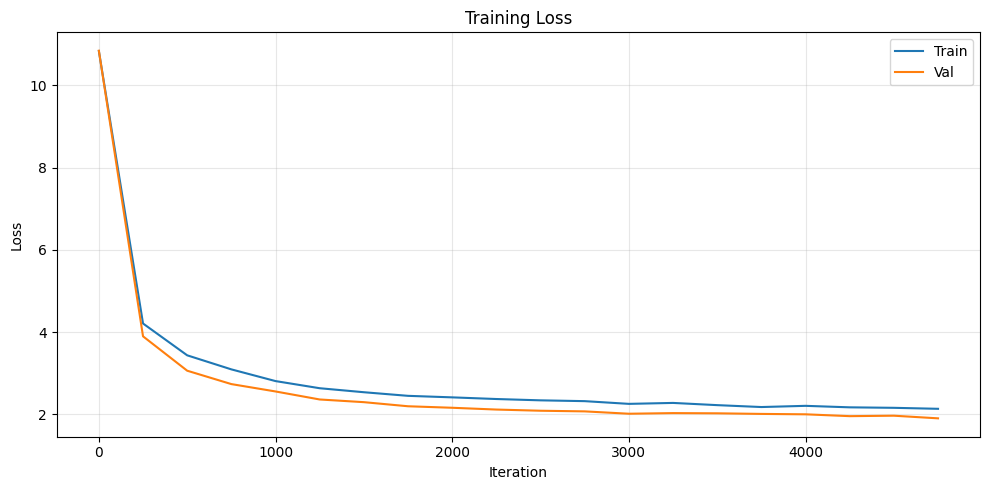

In [19]:
# Plot training curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([x[0] for x in train_losses], [x[1] for x in train_losses], label='Train')
ax.plot([x[0] for x in val_losses], [x[1] for x in val_losses], label='Val')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Sanity Check: Generate Text

In [22]:
# Load best checkpoint
ckpt = torch.load(os.path.join(OUT_DIR, 'best.pt'), map_location=DEVICE, weights_only=False)
model_eval = GPT(ckpt['config']).to(DEVICE)
model_eval.load_state_dict(ckpt['model'])
model_eval.eval()

enc = tiktoken.get_encoding('gpt2')

prompts = [
    "The history of",
    "In the year 1900",
    "Mathematics is",
]

for prompt in prompts:
    tokens = enc.encode(prompt)
    x = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        out = model_eval.generate(x, max_new_tokens=80, temperature=0.8, top_k=40)
    text = enc.decode(out[0].tolist())
    print(f"Prompt: {prompt}")
    print(f"Output: {text}")
    print("-" * 60)

Model initialized: 29.9M parameters
Prompt: The history of
Output: The history of the United States&quot;, John Paul. In the past, John Paul, the First Lieutenant Governor of New York. George Washington was one of the most important British politicians.

Geography

Mary was once the last living person in the country. It is sometimes called &quot;Father of the First Lieutenant Governor of New York&quot;.

Mary is
------------------------------------------------------------
Prompt: In the year 1900
Output: In the year 1900, the population was 3,000.&lt;ref name=&quot;:0&quot; /&gt;

Cities and towns

Sudwig-Holstein is the largest town in the Westphalia. The city of Frankfurt in the municipality is part of the Bavarian district of the canton of Neustadt (women: Schaff
------------------------------------------------------------
Prompt: Mathematics is
Output: Mathematics is a group of scientific systems. A group of scientific systems are the study of scientific system. These are important

## 6. Baseline Evaluation: Next-Token Prediction Accuracy

Measure accuracy under **free generation** (model consumes its own outputs).
This establishes the baseline for comparison with regeneration.

In [24]:
# Evaluation config
NUM_SAMPLES = 300
PROMPT_LEN = 32          # ground truth tokens as prompt
NUM_GENERATE = 224       # tokens to generate (32+224=256=block_size)
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

val_data = np.memmap(os.path.join(DATA_DIR, 'val.bin'), dtype=np.uint16, mode='r')

# Load best model
ckpt = torch.load(os.path.join(OUT_DIR, 'best.pt'), map_location=DEVICE, weights_only=False)
model_eval = GPT(ckpt['config']).to(DEVICE)
model_eval.load_state_dict(ckpt['model'])
model_eval.eval()
print(f"Loaded model, best val loss: {ckpt['best_val_loss']:.4f}")

Model initialized: 29.9M parameters
Loaded model, best val loss: 1.9051


In [25]:
@torch.no_grad()
def generate_greedy(model, prompt, num_tokens):
    """Greedy autoregressive generation."""
    idx = prompt.clone()
    for _ in range(num_tokens):
        idx_cond = idx if idx.size(1) <= model.config.block_size \
            else idx[:, -model.config.block_size:]
        with torch.amp.autocast(device_type=DEVICE, dtype=torch.float16):
            logits, _ = model(idx_cond)
        next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        idx = torch.cat([idx, next_tok], dim=1)
    return idx[:, prompt.size(1):]


# Run baseline evaluation
total_seq_len = PROMPT_LEN + NUM_GENERATE
baseline_accs = []

print(f"Evaluating {NUM_SAMPLES} samples (baseline) ...")
for i in range(NUM_SAMPLES):
    start = np.random.randint(0, len(val_data) - total_seq_len - 1)
    gt = torch.from_numpy(
        val_data[start:start + total_seq_len].astype(np.int64)
    ).to(DEVICE)

    prompt = gt[:PROMPT_LEN].unsqueeze(0)
    gt_gen = gt[PROMPT_LEN:]

    gen = generate_greedy(model_eval, prompt, NUM_GENERATE).squeeze(0)
    acc = (gen == gt_gen).float().mean().item()
    baseline_accs.append(acc)

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{NUM_SAMPLES}] mean acc = {np.mean(baseline_accs):.4f}")

print(f"\nBaseline accuracy: {np.mean(baseline_accs):.4f} +/- {np.std(baseline_accs):.4f}")

Evaluating 300 samples (baseline) ...
  [50/300] mean acc = 0.1442
  [100/300] mean acc = 0.1274
  [150/300] mean acc = 0.1209
  [200/300] mean acc = 0.1293
  [250/300] mean acc = 0.1183
  [300/300] mean acc = 0.1118

Baseline accuracy: 0.1118 +/- 0.1671


## 7. Save Everything for Stage 2

Save the baseline results and model so Stage 2 (regeneration training)
can pick up from here.

In [ ]:
baseline_results = {
    'baseline_accs': baseline_accs,
    'mean': np.mean(baseline_accs),
    'std': np.std(baseline_accs),
    'num_samples': NUM_SAMPLES,
    'prompt_len': PROMPT_LEN,
    'num_generate': NUM_GENERATE,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
}
torch.save(baseline_results, os.path.join(OUT_DIR, 'baseline_results.pt'))

print("Saved:")
print(f"  {OUT_DIR}/best.pt          - best model checkpoint")
print(f"  {OUT_DIR}/final.pt         - final model checkpoint")
print(f"  {OUT_DIR}/baseline_results.pt - baseline evaluation results")
print(f"\nBaseline accuracy: {np.mean(baseline_accs):.4f}")
print(f"\nReady for Stage 2: regeneration training.")

---

## Summary

**What we built:**
- GPT model (~10M params) from scratch with custom attention mask support
- Trained on SimpleWiki with standard causal masking
- Measured baseline next-token prediction accuracy under free generation

**What's next (Stage 2):**
- Load the checkpoint from this notebook
- Continue training with regeneration passes included in the training loop
- The model learns to use the custom mask (bidirectional context)
- Evaluate: does regeneration-trained model improve downstream accuracy?

**Key file:** `out/best.pt` contains the model checkpoint for Stage 2.